# NB02f — American Menu Photo Inventory

**Phase 2, final notebook.** Forensic inventory of the contemporary American menu-image corpus using the real sources currently staged in the repo:

- 55 Yelp American New menu photos
- 6 Wikimedia Commons English-menu supplement images

NYPL's 30 historical Italian menu scans are included as a **quality baseline** in the main comparison figure, but not as part of the American corpus itself.

This notebook is the American counterpart to `NB02c`, using the same visual language and ending with a Phase 3 handoff summary.

| Figure | Description |
|---|---|
| `fig20_american_quality_matrix.png` | Three-source quality matrix: Yelp American vs Wikimedia vs NYPL |
| `fig21_american_contact_sheet.png` | Contact sheet: Yelp American vs Wikimedia at fixed display height |

Run cells top-to-bottom. Inspect each output before proceeding.

## 1. Environment setup

PIL, pandas, matplotlib, and optional LanceDB cross-check. No model load is needed.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

ROOT = Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "configs").exists(), f"Cannot find project root from {Path().resolve()}"

AMERICAN_YELP_DIR = ROOT / "data" / "raw" / "menu_images_comparison" / "american_new"
WIKIMEDIA_DIR     = ROOT / "data" / "raw" / "wikimedia_english_menus"
WIKIMEDIA_MANIFEST = WIKIMEDIA_DIR / "manifest.csv"
NYPL_DIR          = ROOT / "data" / "raw" / "nypl" / "images"
NYPL_RAW          = ROOT / "data" / "raw" / "nypl"
PROCESSED         = ROOT / "data" / "processed"
DB_PATH           = ROOT / "data" / "lancedb"
FIG_DIR           = ROOT / "outputs" / "figures" / "nb02f"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})

print(f"American Yelp dir : {AMERICAN_YELP_DIR}")
print(f"Wikimedia dir     : {WIKIMEDIA_DIR}")
print(f"NYPL dir          : {NYPL_DIR}")
print(f"Figures dir       : {FIG_DIR}")

American Yelp dir : /home/endy/menuforge/data/raw/menu_images_comparison/american_new
Wikimedia dir     : /home/endy/menuforge/data/raw/wikimedia_english_menus
NYPL dir          : /home/endy/menuforge/data/raw/nypl/images
Figures dir       : /home/endy/menuforge/outputs/figures/nb02f


## 2. Build the three-source inventory

Raw files are the source of truth. The notebook scans:

- `data/raw/menu_images_comparison/american_new/` for Yelp American photos
- `data/raw/wikimedia_english_menus/` for the contemporary English-menu supplement
- `data/raw/nypl/images/` plus NYPL metadata for the historical baseline

The final unified frame uses a standard schema across sources and adds source-specific metadata where available.

In [2]:
rows = []

image_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# Yelp American ————————————————————————————————————————————————————————————————
for biz_dir in sorted(AMERICAN_YELP_DIR.iterdir()):
    if not biz_dir.is_dir():
        continue
    for img_path in sorted(p for p in biz_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts):
        with Image.open(img_path) as im:
            w, h = im.size
        rows.append({
            "source": "yelp_american",
            "path": str(img_path),
            "filename": img_path.name,
            "business_id": biz_dir.name,
            "download_w": w,
            "download_h": h,
            "size_bytes": img_path.stat().st_size,
            "page_id": None,
            "orig_w": float("nan"),
            "orig_h": float("nan"),
            "date": None,
            "sponsor": None,
            "place": None,
        })

# Wikimedia supplement ——————————————————————————————————————————————————————————
wikimedia_rows = []
for img_path in sorted(p for p in WIKIMEDIA_DIR.iterdir() if p.is_file() and p.suffix.lower() in image_exts):
    with Image.open(img_path) as im:
        w, h = im.size
    wikimedia_rows.append({
        "source": "wikimedia",
        "path": str(img_path),
        "filename": img_path.name,
        "business_id": None,
        "download_w": w,
        "download_h": h,
        "size_bytes": img_path.stat().st_size,
        "page_id": None,
        "orig_w": float("nan"),
        "orig_h": float("nan"),
        "date": None,
        "sponsor": None,
        "place": None,
    })

wikimedia_df = pd.DataFrame(wikimedia_rows)
if WIKIMEDIA_MANIFEST.exists() and not wikimedia_df.empty:
    manifest = pd.read_csv(WIKIMEDIA_MANIFEST)
    keep = [col for col in ["filename", "title", "url", "mime", "mpx"] if col in manifest.columns]
    wikimedia_df = wikimedia_df.merge(manifest[keep], on="filename", how="left")
    wikimedia_df = wikimedia_df.rename(columns={"title": "commons_title"})
else:
    wikimedia_df["commons_title"] = None
    wikimedia_df["url"] = None
    wikimedia_df["mime"] = None
    wikimedia_df["mpx"] = np.nan

# NYPL baseline ————————————————————————————————————————————————————————————————
nypl_rows = []
for img_path in sorted(p for p in NYPL_DIR.iterdir() if p.is_file() and p.suffix.lower() in image_exts):
    page_id = int(img_path.stem)
    with Image.open(img_path) as im:
        w, h = im.size
    nypl_rows.append({
        "source": "nypl",
        "path": str(img_path),
        "filename": img_path.name,
        "business_id": None,
        "download_w": w,
        "download_h": h,
        "size_bytes": img_path.stat().st_size,
        "page_id": page_id,
        "commons_title": None,
    })

mp = pd.read_csv(NYPL_RAW / "MenuPage.csv", usecols=["id", "menu_id", "full_height", "full_width"])
m = pd.read_csv(NYPL_RAW / "Menu.csv", usecols=["id", "date", "sponsor", "place"])

nypl_df = pd.DataFrame(nypl_rows)
nypl_df = nypl_df.merge(mp, left_on="page_id", right_on="id", how="left")
nypl_df = nypl_df.merge(m, left_on="menu_id", right_on="id", how="left", suffixes=("_page", "_menu"))
nypl_df = nypl_df.rename(columns={"full_width": "orig_w", "full_height": "orig_h"})
nypl_df = nypl_df[[
    "source", "path", "filename", "business_id", "download_w", "download_h",
    "size_bytes", "page_id", "orig_w", "orig_h", "date", "sponsor", "place",
    "commons_title"
]]

# Yelp metadata enrichment ———————————————————————————————————————————————————————
comparison_rest = pd.read_parquet(
    PROCESSED / "comparison_restaurants.parquet",
    columns=["business_id", "name", "city", "stars", "price_range", "cuisine_type"],
)
yelp_df = pd.DataFrame(rows).merge(comparison_rest, on="business_id", how="left")

# Standardised concatenation ————————————————————————————————————————————————————
standard_cols = [
    "source", "path", "filename", "business_id", "download_w", "download_h",
    "size_bytes", "page_id", "orig_w", "orig_h", "date", "sponsor", "place",
    "commons_title", "name", "city", "stars", "price_range"
]
frames = [
    yelp_df.reindex(columns=standard_cols),
    wikimedia_df.reindex(columns=standard_cols),
    nypl_df.reindex(columns=standard_cols),
]
inv = pd.concat(frames, ignore_index=True)

inv["size_kb"] = (inv["size_bytes"] / 1024).round(1)
inv["download_mpx"] = (inv["download_w"] * inv["download_h"] / 1e6).round(3)
inv["orig_mpx"] = (inv["orig_w"] * inv["orig_h"] / 1e6).round(1)
inv["aspect_ratio"] = (inv["download_w"] / inv["download_h"]).round(2)

print(f"Total images     : {len(inv)}")
print(f"  Yelp American  : {(inv['source'] == 'yelp_american').sum()}")
print(f"  Wikimedia      : {(inv['source'] == 'wikimedia').sum()}")
print(f"  NYPL baseline  : {(inv['source'] == 'nypl').sum()}")
print()
print("Yelp American sample:")
print(
    inv.loc[inv["source"] == "yelp_american"]
    .sort_values(["name", "filename"])
    [["name", "city", "stars", "price_range", "download_w", "download_h", "size_kb"]]
    .head(10)
    .to_string(index=False)
)
print()
print("Wikimedia sample:")
print(
    inv.loc[inv["source"] == "wikimedia", ["filename", "commons_title", "download_w", "download_h", "size_kb"]]
    .head(6)
    .to_string(index=False)
)
print()
print("NYPL sample:")
print(
    inv.loc[inv["source"] == "nypl", ["date", "sponsor", "place", "download_w", "download_h", "size_kb", "orig_w", "orig_h"]]
    .head(6)
    .to_string(index=False)
)

Total images     : 91
  Yelp American  : 55
  Wikimedia      : 6
  NYPL baseline  : 30

Yelp American sample:
                                      name         city  stars price_range  download_w  download_h  size_kb
                         2nd Story Brewing Philadelphia    4.0           2         300         400     30.9
                                 717 South        Tampa    4.0           3         309         400     27.0
                      American Sardine Bar Philadelphia    4.0           2         400         400     33.4
                              Boca - Tampa        Tampa    4.0           2         300         400     16.7
                            Bonefish Grill        Tampa    3.5           2         300         400     32.7
               Booker's Restaurant and Bar Philadelphia    3.5           2         300         400     39.2
                  Cerealholic Cafe and Bar        Tampa    4.5        None         242         400     24.0
                        Ch

## 3. Inspect inventory

Per-source aggregate statistics. This is the evidence pass before plotting:

- Yelp American: contemporary but low-information thumbnails
- Wikimedia: contemporary, small-N, high-resolution supplement
- NYPL: historical, mid-resolution baseline with structured metadata

In [3]:
SOURCE_LABELS = {
    "yelp_american": "Yelp American",
    "wikimedia": "Wikimedia",
    "nypl": "NYPL baseline",
}

for src in ["yelp_american", "wikimedia", "nypl"]:
    grp = inv[inv["source"] == src]
    print(f"── {SOURCE_LABELS[src]} ({len(grp)} images) ──")
    print(f"  Download resolution")
    print(f"    width   : {grp['download_w'].min():.0f} – {grp['download_w'].max():.0f} px  "
          f"(mean {grp['download_w'].mean():.0f})")
    print(f"    height  : {grp['download_h'].min():.0f} – {grp['download_h'].max():.0f} px  "
          f"(mean {grp['download_h'].mean():.0f})")
    print(f"    Mpx     : {grp['download_mpx'].min():.3f} – {grp['download_mpx'].max():.3f}  "
          f"(mean {grp['download_mpx'].mean():.3f})")
    if grp["orig_mpx"].notna().any():
        print(f"  Original archive resolution (NYPL only)")
        print(f"    width   : {grp['orig_w'].min():.0f} – {grp['orig_w'].max():.0f} px")
        print(f"    height  : {grp['orig_h'].min():.0f} – {grp['orig_h'].max():.0f} px")
        print(f"    Mpx     : {grp['orig_mpx'].min():.1f} – {grp['orig_mpx'].max():.1f}  "
              f"(mean {grp['orig_mpx'].mean():.1f})")
    print(f"  File size")
    print(f"    min     : {grp['size_kb'].min():.1f} KB")
    print(f"    max     : {grp['size_kb'].max():.1f} KB")
    print(f"    mean    : {grp['size_kb'].mean():.1f} KB")
    print(f"  Aspect ratio")
    print(f"    min     : {grp['aspect_ratio'].min():.2f}")
    print(f"    max     : {grp['aspect_ratio'].max():.2f}")
    print(f"    mean    : {grp['aspect_ratio'].mean():.2f}")
    print()

wiki_mean = inv.loc[inv["source"] == "wikimedia", "download_mpx"].mean()
print(f"Wikimedia adequacy gate (mean >= 0.3 Mpx): {wiki_mean:.3f} Mpx")


── Yelp American (55 images) ──
  Download resolution
    width   : 201 – 600 px  (mean 361)
    height  : 245 – 400 px  (mean 389)
    Mpx     : 0.080 – 0.240  (mean 0.138)
  File size
    min     : 9.6 KB
    max     : 81.4 KB
    mean    : 32.2 KB
  Aspect ratio
    min     : 0.50
    max     : 2.45
    mean    : 0.96

── Wikimedia (6 images) ──
  Download resolution
    width   : 8160 – 8160 px  (mean 8160)
    height  : 6144 – 6144 px  (mean 6144)
    Mpx     : 50.135 – 50.135  (mean 50.135)
  File size
    min     : 6290.6 KB
    max     : 8959.0 KB
    mean    : 7598.7 KB
  Aspect ratio
    min     : 1.33
    max     : 1.33
    mean    : 1.33

── NYPL baseline (30 images) ──
  Download resolution
    width   : 235 – 760 px  (mean 530)
    height  : 547 – 760 px  (mean 753)
    Mpx     : 0.179 – 0.459  (mean 0.398)
  Original archive resolution (NYPL only)
    width   : 1898 – 5796 px
    height  : 2823 – 6589 px
    Mpx     : 5.4 – 26.1  (mean 15.5)
  File size
    min     : 50.

## 4. Figure 20 — American menu-image quality matrix

Two panels in one figure:

- **Left — Resolution scatter:** width × height, coloured by source, bubble area proportional   to file size.
- **Right — File-size distribution:** violin + strip plot by source.

The intended read is structural: Yelp American occupies the low-resolution floor, NYPL provides a historical mid-range baseline, and Wikimedia is the contemporary high-resolution supplement that makes qualitative American VLM work plausible.

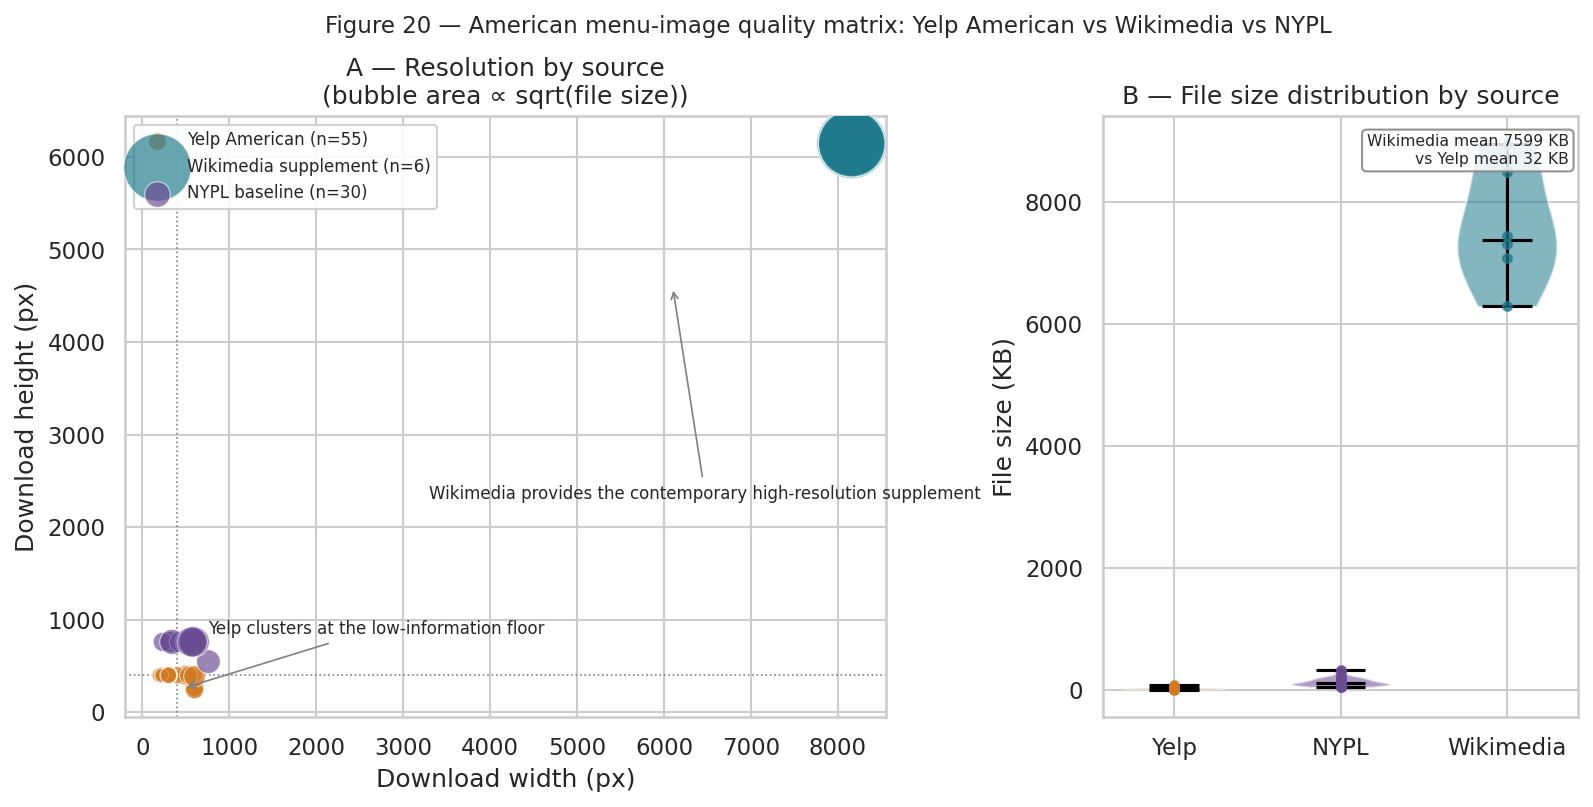

Saved: outputs/figures/nb02f/fig20_american_quality_matrix.png


In [4]:
SOURCE_COLORS = {
    "yelp_american": "#D17A22",
    "wikimedia": "#1F7A8C",
    "nypl": "#6A4C93",
}

fig = plt.figure(figsize=(12.5, 5.2))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1], wspace=0.35)

# Panel A — scatter ————————————————————————————————————————————————————————————
ax_scatter = fig.add_subplot(gs[0])

for src, label in [
    ("yelp_american", "Yelp American (n=55)"),
    ("wikimedia", "Wikimedia supplement (n=6)"),
    ("nypl", "NYPL baseline (n=30)"),
]:
    grp = inv[inv["source"] == src]
    ax_scatter.scatter(
        grp["download_w"],
        grp["download_h"],
        s=np.sqrt(grp["size_kb"].clip(lower=1)) * 12,
        color=SOURCE_COLORS[src],
        alpha=0.68,
        edgecolors="white",
        linewidths=0.5,
        label=label,
        zorder=3,
    )

ax_scatter.set_xlabel("Download width (px)")
ax_scatter.set_ylabel("Download height (px)")
ax_scatter.set_title("A — Resolution by source\n(bubble area ∝ sqrt(file size))")
ax_scatter.axhline(400, color="grey", linestyle=":", linewidth=0.8)
ax_scatter.axvline(400, color="grey", linestyle=":", linewidth=0.8)
ax_scatter.legend(fontsize=8, framealpha=0.9, loc="upper left")

ax_scatter.annotate(
    "Yelp clusters at the low-information floor",
    xy=(470, 260), xycoords="data",
    xytext=(760, 850), textcoords="data",
    arrowprops=dict(arrowstyle="->", color="grey", lw=0.8),
    fontsize=8,
)
ax_scatter.annotate(
    "Wikimedia provides the contemporary high-resolution supplement",
    xy=(6100, 4600), xycoords="data",
    xytext=(3300, 2300), textcoords="data",
    arrowprops=dict(arrowstyle="->", color="grey", lw=0.8),
    fontsize=8,
)

# Panel B — violin / strip ————————————————————————————————————————————————————
ax_vio = fig.add_subplot(gs[1])

vio_order = [
    ("yelp_american", "Yelp"),
    ("nypl", "NYPL"),
    ("wikimedia", "Wikimedia"),
]
for i, (src, tick_label) in enumerate(vio_order):
    vals = inv.loc[inv["source"] == src, "size_kb"].values
    parts = ax_vio.violinplot(vals, positions=[i], widths=0.6, showmedians=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(SOURCE_COLORS[src])
        pc.set_alpha(0.55)
    parts["cmedians"].set_color("black")
    parts["cbars"].set_color("black")
    parts["cmins"].set_color("black")
    parts["cmaxes"].set_color("black")
    ax_vio.scatter([i] * len(vals), vals, color=SOURCE_COLORS[src], s=18, alpha=0.72, zorder=3)

ax_vio.set_xticks([0, 1, 2])
ax_vio.set_xticklabels([lbl for _, lbl in vio_order])
ax_vio.set_ylabel("File size (KB)")
ax_vio.set_title("B — File size distribution by source")

yelp_mean = inv.loc[inv["source"] == "yelp_american", "size_kb"].mean()
wiki_mean_kb = inv.loc[inv["source"] == "wikimedia", "size_kb"].mean()
ax_vio.annotate(
    f"Wikimedia mean {wiki_mean_kb:.0f} KB\nvs Yelp mean {yelp_mean:.0f} KB",
    xy=(0.98, 0.97), xycoords="axes fraction",
    ha="right", va="top", fontsize=7.5,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.85),
)

fig.suptitle(
    "Figure 20 — American menu-image quality matrix: Yelp American vs Wikimedia vs NYPL",
    fontsize=11,
    y=1.01,
)

out = FIG_DIR / "fig20_american_quality_matrix.png"
fig.savefig(out)
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")

## 5. Figure 21 — American menu contact sheet

The contact sheet stays focused on the American corpus only:

- Yelp American: top 8 images by file size
- Wikimedia: all available images up to 8, sorted by file size descending

All thumbnails are displayed at the same height so legibility and document structure can be compared directly without repeated images.

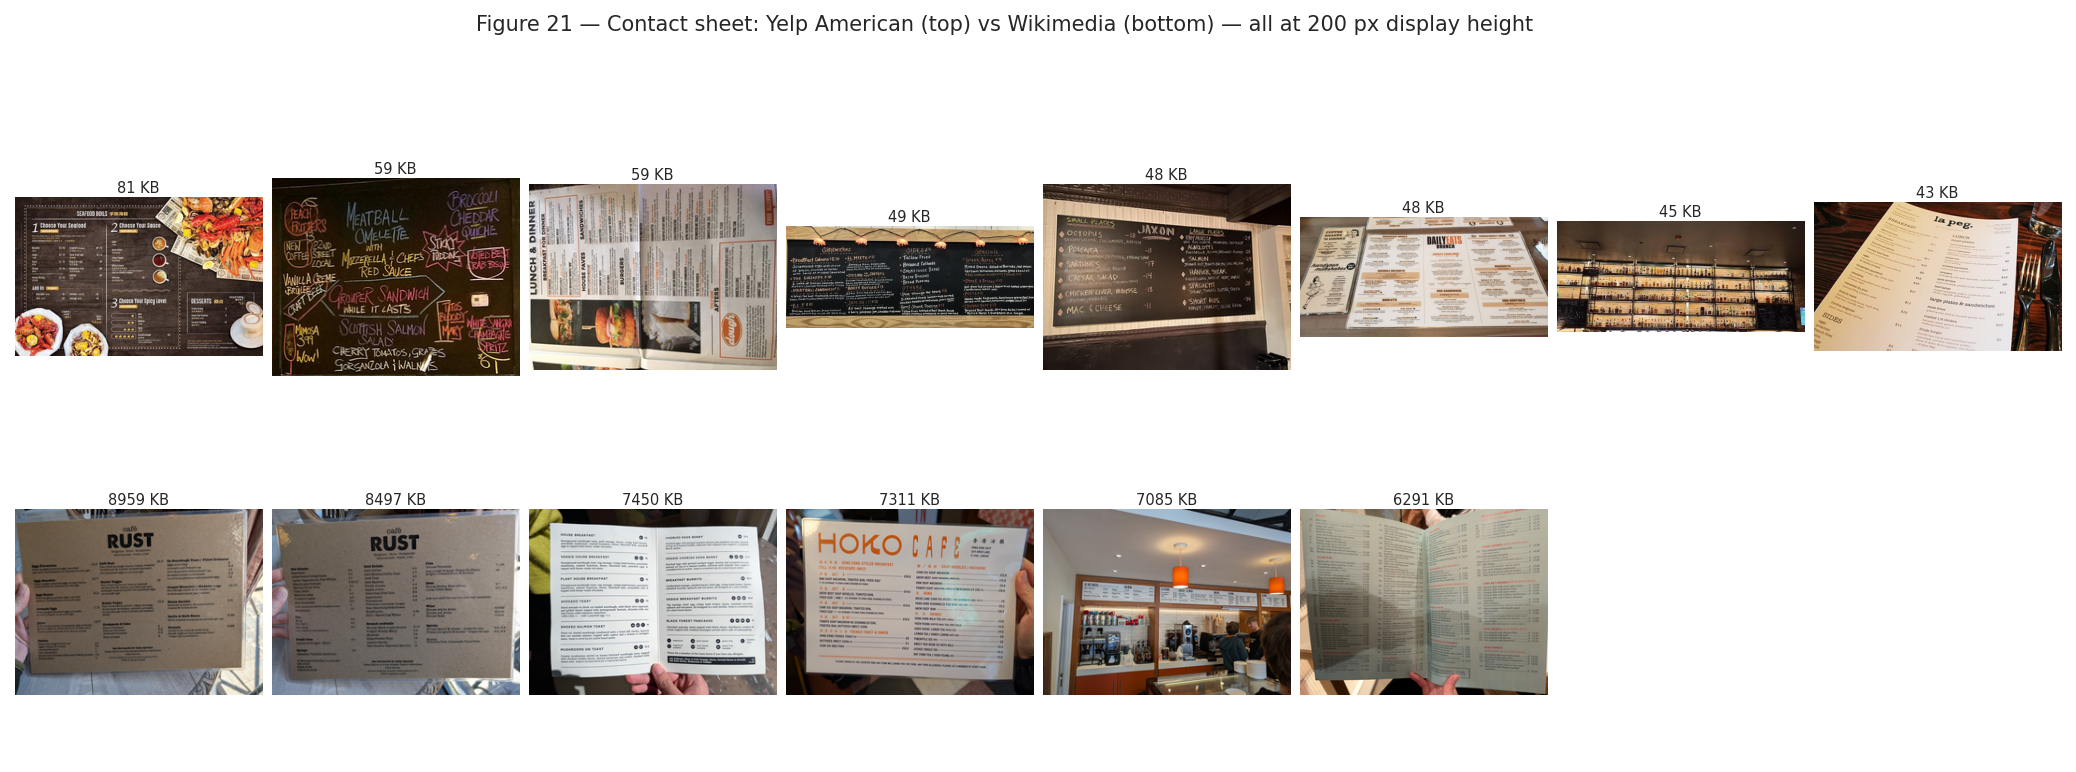

Saved: outputs/figures/nb02f/fig21_american_contact_sheet.png

Visual check:
  - Yelp should look like low-resolution user-submitted thumbnails.
  - Wikimedia should show fuller page structure and more legible text.
  - Blank Wikimedia cells are expected because the supplement only has 6 images.


In [5]:
THUMB_H = 200

def make_thumb(path, target_h=THUMB_H):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    new_w = max(1, int(w * target_h / h))
    return img.resize((new_w, target_h), Image.LANCZOS)

yelp_sel = (
    inv[inv["source"] == "yelp_american"]
    .sort_values("size_kb", ascending=False)
    .head(8)["path"]
    .tolist()
)

wikimedia_sel = (
    inv[inv["source"] == "wikimedia"]
    .sort_values("size_kb", ascending=False)
    .head(8)["path"]
    .tolist()
)

n_cols = 8
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 2.2, 5.5))
fig.subplots_adjust(hspace=0.05, wspace=0.04)

row_labels = [
    "Yelp American (top-8 by file size)",
    "Wikimedia supplement (all available, max 8)",
]
row_paths = [yelp_sel, wikimedia_sel]

for row_idx, (label, paths) in enumerate(zip(row_labels, row_paths)):
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        if col_idx < len(paths):
            thumb = make_thumb(paths[col_idx])
            ax.imshow(np.array(thumb))
            kb = Path(paths[col_idx]).stat().st_size / 1024
            ax.set_title(f"{kb:.0f} KB", fontsize=7, pad=2)
        ax.axis("off")
    axes[row_idx, 0].set_ylabel(label, fontsize=8, rotation=0, labelpad=5, ha="right", va="center")

fig.suptitle(
    "Figure 21 — Contact sheet: Yelp American (top) vs Wikimedia (bottom) "
    f"— all at {THUMB_H} px display height",
    fontsize=10,
    y=1.01,
)

out = FIG_DIR / "fig21_american_contact_sheet.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")
print()
print("Visual check:")
print("  - Yelp should look like low-resolution user-submitted thumbnails.")
print("  - Wikimedia should show fuller page structure and more legible text.")
print("  - Blank Wikimedia cells are expected because the supplement only has 6 images.")

## 6. Summary card — NB02f

Key numbers, gate checks, and data-honesty notes for the final Phase 2 handoff into Phase 3.

In [6]:
print("=" * 64)
print("NB02f SUMMARY — American menu photo inventory")
print("=" * 64)

for src in ["yelp_american", "wikimedia", "nypl"]:
    grp = inv[inv["source"] == src]
    print(f"\n── {SOURCE_LABELS[src]} ──")
    print(f"  Images        : {len(grp)}")
    print(f"  Mean Mpx      : {grp['download_mpx'].mean():.3f}")
    print(f"  Min/Max Mpx   : {grp['download_mpx'].min():.3f} / {grp['download_mpx'].max():.3f}")
    print(f"  Mean KB       : {grp['size_kb'].mean():.1f}")
    print(f"  Min/Max KB    : {grp['size_kb'].min():.1f} / {grp['size_kb'].max():.1f}")

wiki_mean = inv.loc[inv["source"] == "wikimedia", "download_mpx"].mean()
print("\n── Gate check ──")
print(f"  Wikimedia mean download resolution >= 0.3 Mpx : [{'OK' if wiki_mean >= 0.3 else 'CHECK'}]  {wiki_mean:.3f} Mpx")

print("\n── Data honesty ──")
print("  - Wikimedia is a small qualitative supplement, not ground truth.")
print("  - Yelp photos are server-scaled thumbnails rather than original uploads.")
print("  - NYPL is historical and only serves as a quality baseline here, not as contemporary American menu data.")
print("  - Only NYPL has structured ground-truth metadata; the American corpus supports qualitative VLM demonstration only.")

print("\n── Figures saved ──")
for f in sorted(FIG_DIR.glob('fig*.png')):
    print(f"  {f.name}")

print("\nNext: Phase 3 preprocessing and knowledge-base construction.")

NB02f SUMMARY — American menu photo inventory

── Yelp American ──
  Images        : 55
  Mean Mpx      : 0.138
  Min/Max Mpx   : 0.080 / 0.240
  Mean KB       : 32.2
  Min/Max KB    : 9.6 / 81.4

── Wikimedia ──
  Images        : 6
  Mean Mpx      : 50.135
  Min/Max Mpx   : 50.135 / 50.135
  Mean KB       : 7598.7
  Min/Max KB    : 6290.6 / 8959.0

── NYPL baseline ──
  Images        : 30
  Mean Mpx      : 0.398
  Min/Max Mpx   : 0.179 / 0.459
  Mean KB       : 136.7
  Min/Max KB    : 50.4 / 323.6

── Gate check ──
  Wikimedia mean download resolution >= 0.3 Mpx : [OK]  50.135 Mpx

── Data honesty ──
  - Wikimedia is a small qualitative supplement, not ground truth.
  - Yelp photos are server-scaled thumbnails rather than original uploads.
  - NYPL is historical and only serves as a quality baseline here, not as contemporary American menu data.
  - Only NYPL has structured ground-truth metadata; the American corpus supports qualitative VLM demonstration only.

── Figures saved ──
  fi